#Analisis Pola Kunjungan Lokasi Pengguna Gowalla Berdasarkan Waktu dan Tren Global

Anggota Kelompok 13:
1. Elok Fiola – 122450051 (Ketua Kelompok)     
2. Nabila Anilda Zahrah – 122450063 (Anggota Kelompok)   
3. Eka Fidiya Putri – 122450045 (Anggota Kelompok)

# 2. Implementation

## 2.1. Preprocessing Dataset

### 2.1.1. Understanding Data
Pada tahap ini dilakukan untuk memahami data sebelum dilakukan analisis lebih lanjut. Tahap ini dilakukan *import* dataset, periksaan struktur dataset, tipe data, identifikasi jumlah baris dan kolom untuk memahami ukuran dataset.

In [ ]:
#import library
import pandas as pd
from IPython.display import display, HTML

#### a. Import Dataset dan Periksa Struktur Data

In [ ]:
#import data gowalla userinfo excel
data_userinfo = pd.read_excel('/content/gowalla_userinfo.xlsx')
data_userinfo.head()

,id,bookmarked_spots_count,challenge_pin_count,country_pin_count,highlights_count,items_count,photos_count,pins_count,province_pin_count,region_pin_count,state_pin_count,trips_count,friends_count,stamps_count,checkin_num,places_num
0,1,26,59,1,29,18,135,85,0,13,12,2,372,757,1766,756
1,2,36,79,12,117,29,1069,138,0,31,19,7,775,1227,2892,1220
2,3,11,70,1,42,49,149,93,0,7,6,2,100,905,3021,905
3,4,7,51,1,13,29,138,80,0,13,12,1,179,608,1325,613
4,5,34,82,5,62,36,1012,134,0,19,14,2,525,1124,3215,1124


In [ ]:
#import data gowalla frindship
data_friendship = pd.read_excel('/content/gowalla_friendship.xlsx')
data_friendship.head()

,userid1,userid2
0,1,63488
1,1,2
2,1,3
3,1,4
4,1,5


In [10]:
#import data gowalla spots subset1
data_spots1 = pd.read_excel('/content/gowalla_spots_subset1.xlsx')
data_spots1.head()

,id,created_at,lng,lat,photos_count,checkins_count,users_count,radius_meters,highlights_count,items_count,max_items_count,spot_categories
0,8904,2008-12-06T16:28:53Z,-94.607499,39.052318,0,114,21,35,0,10,10,"[{'url': '/categories/89', 'name': 'Craftsman'}]"
1,8932,2008-12-13T02:16:51Z,-97.254356,32.927662,2,67,48,75,0,6,10,"[{'url': '/categories/17', 'name': 'BBQ'}]"
2,8936,2008-12-14T22:08:39Z,-94.591995,39.053318,0,75,46,75,0,10,10,"[{'url': '/categories/103', 'name': 'Theatre'}]"
3,8938,2008-12-15T00:22:49Z,-94.590311,39.052824,38,438,94,50,10,10,10,"[{'url': '/categories/1', 'name': 'Coffee Shop'}]"
4,8947,2008-12-16T23:14:05Z,-122.029631,37.331880,91,3100,1186,200,20,10,10,"[{'url': '/categories/121', 'name': 'Corporate..."


In [11]:
#import data gowalla spots subset2 dan membaca 'null' sebagai missing value
data_spots2 = pd.read_excel('/content/gowalla_spots_subset2.xlsx', na_values=['null'])
data_spots2.head()

,id,lat,lng,name,city_state,Unnamed: 5,Unnamed: 6
0,9813,36.631508,-121.912022,Pacific Ocean,"Seaside, CA",NaN,NaN
1,11981,40.690173,-74.045491,Refreshment Park,"New York, NY",NaN,NaN
2,12455,36.642022,-93.284912,Mickey Gilley Theatre,"Branson, MO",NaN,NaN
3,12455,36.642022,-93.284912,Mickey Gilley Theatre,"Branson, MO",NaN,NaN
4,13810,42.548879,-82.902768,Jaword,"Clinton, MI",NaN,NaN


In [12]:
#import data gowalla checkins
data_checkins = pd.read_excel('/content/gowalla_checkins.xlsx')
data_checkins.head()

,userid,placeid,datetime
0,1338,482954,2011-06-23T02:24:22Z
1,1338,580963,2011-06-22T14:23:03Z
2,1338,365256,2011-06-09T23:29:30Z
3,1338,89504,2011-05-22T15:54:30Z
4,1338,1267135,2011-05-21T16:51:13Z


#### b. Memeriksa tipe data

In [13]:
#cek tipe data gowalla userinfo
data_userinfo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407533 entries, 0 to 407532
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   id                      407533 non-null  int64
 1   bookmarked_spots_count  407533 non-null  int64
 2   challenge_pin_count     407533 non-null  int64
 3   country_pin_count       407533 non-null  int64
 4   highlights_count        407533 non-null  int64
 5   items_count             407533 non-null  int64
 6   photos_count            407533 non-null  int64
 7   pins_count              407533 non-null  int64
 8   province_pin_count      407533 non-null  int64
 9   region_pin_count        407533 non-null  int64
 10  state_pin_count         407533 non-null  int64
 11  trips_count             407533 non-null  int64
 12  friends_count           407533 non-null  int64
 13  stamps_count            407533 non-null  int64
 14  checkin_num             407533 non-null  int64
 15  

In [14]:
#cek tipe data gowalla friendship
data_friendship.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 2 columns):
 #   Column   Non-Null Count    Dtype
---  ------   --------------    -----
 0   userid1  1048575 non-null  int64
 1   userid2  1048575 non-null  int64
dtypes: int64(2)
memory usage: 16.0 MB


In [15]:
#cek tipe data gowalla spots subset1
data_spots1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1048575 non-null  int64  
 1   created_at        1048575 non-null  object 
 2   lng               1048575 non-null  float64
 3   lat               1048575 non-null  float64
 4   photos_count      1048575 non-null  int64  
 5   checkins_count    1048575 non-null  int64  
 6   users_count       1048575 non-null  int64  
 7   radius_meters     1048575 non-null  int64  
 8   highlights_count  1048575 non-null  int64  
 9   items_count       1048575 non-null  int64  
 10  max_items_count   1048575 non-null  int64  
 11  spot_categories   1048575 non-null  object 
dtypes: float64(2), int64(8), object(2)
memory usage: 96.0+ MB


In [16]:
#cek tipe data gowalla spots subset2
data_spots2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120997 entries, 0 to 120996
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          120997 non-null  int64  
 1   lat         120997 non-null  float64
 2   lng         120997 non-null  float64
 3   name        120996 non-null  object 
 4   city_state  107033 non-null  object 
 5   Unnamed: 5  5 non-null       object 
 6   Unnamed: 6  1 non-null       object 
dtypes: float64(2), int64(1), object(4)
memory usage: 6.5+ MB


In [17]:
#cek tipe data gowalla checkins
data_checkins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   userid    1048575 non-null  int64 
 1   placeid   1048575 non-null  int64 
 2   datetime  1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


#### c.  identifikasi jumlah baris dan kolom

In [18]:
#cek shape data gowalla userinfo
print(data_userinfo.shape)

(407533, 16)


In [19]:
#cek shape data gowalla frienship
print(data_friendship.shape)

(1048575, 2)


In [20]:
#cek shape dan nilai hilang data gowalla spots1
print(data_spots1.shape)

(1048575, 12)


In [21]:
#cek shape dan nilai hilang data gowalla spots2
print(data_spots2.shape)

(120997, 7)


In [22]:
#cek shape dan nilai hilang data gowalla checkins
print(data_checkins.shape)

(1048575, 3)


### 2.1.2. Penanganan Data Kosong (Missing Values)

In [23]:
#cek nilai hilang data gowalla userinfo
print(data_userinfo.isnull().sum())

id                        0
bookmarked_spots_count    0
challenge_pin_count       0
country_pin_count         0
highlights_count          0
items_count               0
photos_count              0
pins_count                0
province_pin_count        0
region_pin_count          0
state_pin_count           0
trips_count               0
friends_count             0
stamps_count              0
checkin_num               0
places_num                0
dtype: int64


In [24]:
#cek nilai hilang data gowalla frienship
print(data_friendship.isnull().sum())

userid1    0
userid2    0
dtype: int64


In [25]:
#cek nilai hilang data gowalla spots1
print(data_spots1.isnull().sum())

id                  0
created_at          0
lng                 0
lat                 0
photos_count        0
checkins_count      0
users_count         0
radius_meters       0
highlights_count    0
items_count         0
max_items_count     0
spot_categories     0
dtype: int64


In [26]:
#cek nilai hilang data gowalla spots2
print(data_spots2.isnull().sum())

id                 0
lat                0
lng                0
name               1
city_state     13964
Unnamed: 5    120992
Unnamed: 6    120996
dtype: int64


In [27]:
#cek nilai hilang data gowalla checkins
print(data_checkins.isnull().sum())

userid      0
placeid     0
datetime    0
dtype: int64


Ternyata terdapat nilai kosong pada data gowalla spots2, selanjutnya dilakukan penanganan nilai koson tersebut

In [28]:
#Menangani missing value gowalla spots2
#mengisi missing value pada kolom "name" dengan "Unknown"
data_spots2['name'].fillna('Unknown')

#Mengganti missing value pada kolom "city_state" dengan 'Unknown'
data_spots2['city_state'].fillna('Unknown')

# Ganti nilai yang mengandung garis miring '\' dengan 'Unknown'
data_spots2['name'] = data_spots2['name'].apply(
    lambda x: 'Unknown' if isinstance(x, str) and '\\' in x else x
)

#cek kembali missing value gowalla spots2
data_spots2.isnull().sum()

,0
id,0
lat,0
lng,0
name,1
city_state,13964
Unnamed: 5,120992
Unnamed: 6,120996


In [29]:
#Menghapus kolom yang tidak relevan pada data gowalla spots subset2
data_spots2.drop(columns=['Unnamed: 5', 'Unnamed: 6'], inplace=True)
data_spots2.head()

,id,lat,lng,name,city_state
0,9813,36.631508,-121.912022,Pacific Ocean,"Seaside, CA"
1,11981,40.690173,-74.045491,Refreshment Park,"New York, NY"
2,12455,36.642022,-93.284912,Mickey Gilley Theatre,"Branson, MO"
3,12455,36.642022,-93.284912,Mickey Gilley Theatre,"Branson, MO"
4,13810,42.548879,-82.902768,Jaword,"Clinton, MI"


In [30]:
#Memastikan dimensi data tidak berubah
print(data_spots1.shape)

#Cek kembali informasi data
print(data_spots2.isnull().sum())

(1048575, 12)
id                0
lat               0
lng               0
name              1
city_state    13964
dtype: int64


In [31]:
# Menampilkan 5 baris acak dari data_spots2
data_spots2.sample(n=5)

,id,lat,lng,name,city_state
54955,6528643,40.115070,-85.667538,The Bros,"Anderson, IN"
117271,7523220,41.345278,-81.735572,Frame Shop,"North Royalton, OH"
110202,7441353,57.489397,12.240173,Unknown,Kungsbacka Skene
84724,7092099,50.371117,12.910915,Unknown,J\\u00e1chymov
48316,6378771,24.690257,46.659064,Home,Riyadh


### 2.1.3 Feature Engineering dan Cleaning Data

In [32]:
# Membuat salinan data asli
data_spots2_new = data_spots2.copy()

# Memisahkan kolom city_state menjadi city (kota) dan country (negara)
data_spots2_new[['city', 'country']] = data_spots2_new['city_state'].str.split(',', expand=True)

# Menghapus spasi di awal dan akhir (jika ada)
data_spots2_new['city'] = data_spots2_new['city'].str.strip()
data_spots2_new['country'] = data_spots2_new['country'].str.strip()

# Menghapus kolom city_state
data_spots2_new.drop(columns=['city_state'], inplace=True)

# Mengganti nilai None atau NaN di kolom 'country' menjadi 'Unknown'
data_spots2_new['country'] = data_spots2_new['country'].fillna('Unknown')

# Menampilkan hasil
data_spots2_new.head(15)

,id,lat,lng,name,city,country
0,9813,36.631508,-121.912022,Pacific Ocean,Seaside,CA
1,11981,40.690173,-74.045491,Refreshment Park,New York,NY
2,12455,36.642022,-93.284912,Mickey Gilley Theatre,Branson,MO
3,12455,36.642022,-93.284912,Mickey Gilley Theatre,Branson,MO
4,13810,42.548879,-82.902768,Jaword,Clinton,MI
5,13810,42.548879,-82.902768,Jaword,Clinton,MI
6,14800,42.441248,-82.905922,Lax field,Grosse Pointe,MI
7,14800,42.441248,-82.905922,Lax field,Grosse Pointe,MI
8,14869,42.464765,-82.897403,Harper Sports,St. Clair Shores,MI
9,14869,42.464765,-82.897403,Harper Sports,St. Clair Shores,MI


In [33]:
# Transformasi Data gowalla_spots_subset1
data_spots1.columns = data_spots1.columns.str.strip()
data_spots1['created_at'] = pd.to_datetime(data_spots1['created_at'], utc=True)

data_datetime_transformed = pd.DataFrame({
    'tahun': data_spots1['created_at'].dt.year,
    'bulan': data_spots1['created_at'].dt.month,
    'waktu': data_spots1['created_at'].dt.hour
})

In [34]:
# Gabungkan dataset berdasarkan posisi baris
data_spots1[['tahun', 'bulan', 'waktu']] = data_datetime_transformed[['tahun', 'bulan', 'waktu']]

In [35]:
# Hapus kolom 'created_at'
data_spots1 = data_spots1.drop(columns=['created_at'])

# Pindahkan kolom 'tahun', 'bulan', dan 'waktu' ke samping kolom 'id'
cols = list(data_spots1.columns)  # Dapatkan daftar kolom

# Atur ulang urutan kolom
new_order = ['id', 'tahun', 'bulan', 'waktu'] + [col for col in cols if col not in ['id', 'tahun', 'bulan', 'waktu']]
data_spots1 = data_spots1[new_order]

# Tampilkan informasi dataset yang diperbarui
print(data_spots1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 14 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1048575 non-null  int64  
 1   tahun             1048575 non-null  int32  
 2   bulan             1048575 non-null  int32  
 3   waktu             1048575 non-null  int32  
 4   lng               1048575 non-null  float64
 5   lat               1048575 non-null  float64
 6   photos_count      1048575 non-null  int64  
 7   checkins_count    1048575 non-null  int64  
 8   users_count       1048575 non-null  int64  
 9   radius_meters     1048575 non-null  int64  
 10  highlights_count  1048575 non-null  int64  
 11  items_count       1048575 non-null  int64  
 12  max_items_count   1048575 non-null  int64  
 13  spot_categories   1048575 non-null  object 
dtypes: float64(2), int32(3), int64(8), object(1)
memory usage: 100.0+ MB
None


In [36]:
# Menampilkan tabel dengan scroll
display(HTML(data_spots1.head(5).to_html(max_rows=10, max_cols=10, notebook=True)))

,id,tahun,bulan,waktu,lng,...,radius_meters,highlights_count,items_count,max_items_count,spot_categories
0,8904,2008,12,16,-94.607499,...,35,0,10,10,"[{'url': '/categories/89', 'name': 'Craftsman'}]"
1,8932,2008,12,2,-97.254356,...,75,0,6,10,"[{'url': '/categories/17', 'name': 'BBQ'}]"
2,8936,2008,12,22,-94.591995,...,75,0,10,10,"[{'url': '/categories/103', 'name': 'Theatre'}]"
3,8938,2008,12,0,-94.590311,...,50,10,10,10,"[{'url': '/categories/1', 'name': 'Coffee Shop'}]"
4,8947,2008,12,23,-122.029631,...,200,20,10,10,"[{'url': '/categories/121', 'name': 'Corporate..."


In [37]:
#Transformasi data gowalla_checkins
data_checkins.columns = data_checkins.columns.str.strip()
data_checkins['datetime'] = pd.to_datetime(data_checkins['datetime'], utc=True)

data_waktu_checkins = pd.DataFrame({
    'tahun': data_checkins['datetime'].dt.year,
    'bulan': data_checkins['datetime'].dt.month,
    'waktu': data_checkins['datetime'].dt.hour
})

In [38]:
# Urutkan data berdasarkan kolom 'tahun', 'bulan', dan 'waktu'
data_waktu_checkins = data_waktu_checkins.sort_values(by=['tahun', 'bulan', 'waktu']).reset_index(drop=True)

# Tampilkan data yang telah diurutkan
print(data_waktu_checkins.head())

   tahun  bulan  waktu
0   2009      3      0
1   2009      3      0
2   2009      3      0
3   2009      3      0
4   2009      3      0


### 2.1.4 Data Integration

In [39]:
#Menggabungkan data gowalla_spots_subset1 dan gowalla_checkins
#Menggabungkan waktu checkins untuk melihat total checkins di sepanjang tahun 2008 - 2011
data_checkins_langkap = pd.concat([data_datetime_transformed, data_waktu_checkins], ignore_index=True)
data_checkins_langkap

,tahun,bulan,waktu
0,2008,12,16
1,2008,12,2
2,2008,12,22
3,2008,12,0
4,2008,12,23
...,...,...,...
2097145,2011,7,23
2097146,2011,7,23
2097147,2011,7,23
2097148,2011,7,23


In [40]:
#Cek dimensi setelah digabungkan
data_checkins_langkap.shape

(2097150, 3)

In [41]:
#Cek missing value
data_checkins_langkap.isnull().sum()

,0
tahun,0
bulan,0
waktu,0


In [42]:
import pandas as pd

# Mengelompokkan data dan menghitung jumlah check-ins
monthly_checkins = (
    data_checkins_langkap.groupby(['tahun', 'bulan'])
    .size()
    .reset_index(name='total_checkins')  # Ini sudah menghasilkan DataFrame
)

print(monthly_checkins.head(5))

   tahun  bulan  total_checkins
0   2008     12              14
1   2009      1              26
2   2009      2             174
3   2009      3            1330
4   2009      4            1803


## Visualisasi dan Analisis

### 2.2.1. Pertanyaan 1: Siapa pengguna dengan jumlah check-in terbanyak, dan lokasi mana yang paling sering ia kunjungi?   

In [43]:
# Mencari ID dengan jumlah jumlah check-in terbanyak
max_checkins = data_userinfo.loc[data_userinfo["checkin_num"].idxmax()]
print(f"ID dengan jumlah check-in terbanyak {max_checkins['id']} dengan total {max_checkins['checkin_num']} check-ins.")

ID dengan jumlah check-in terbanyak 84414 dengan total 46981 check-ins.


In [44]:
# Filter data tempat yang dikunjungi
places_visited = data_spots1[data_spots1["id"] == 46981][["spot_categories", "lng", "lat"]]

# Menampilkan data dengan format rapi
print("Tempat yang paling sering dikunjungi:")
print(places_visited.to_string(index=False))

Tempat yang paling sering dikunjungi:
                                         spot_categories        lng       lat
[{'url': '/categories/119', 'name': 'Gas & Automotive'}] -122.14764 37.425774


### 2.2.2. Pertanyaan 2: Apakah mereka yang semakin banyak melakukan checkins akan semakin banyak memiliki teman?

Korelasi antara jumlah check-in dan jumlah teman: 0.12 (p-value: 0.00e+00)


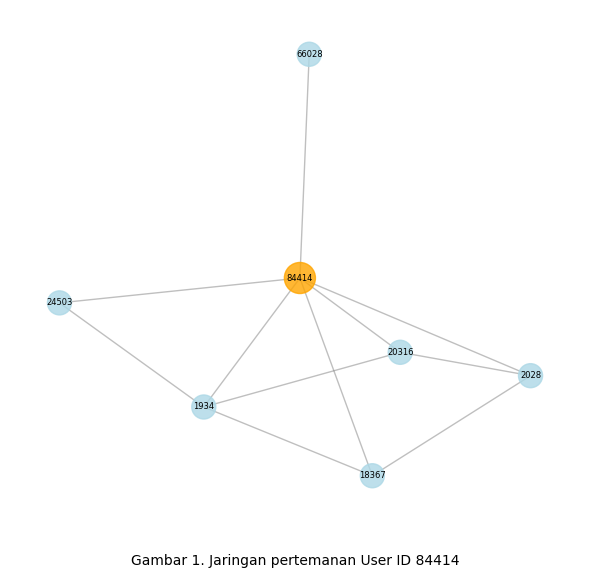

In [46]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Membuat graf dari DataFrame
G = nx.from_pandas_edgelist(data_friendship, 'userid1', 'userid2')

# Pilih userid2 yang ingin dianalisis
target_userid2 = 84414  # Ganti dengan userid2 yang diinginkan

# Membuat subgraf untuk target_userid2 dan semua tetangganya
subgraph = G.subgraph([target_userid2] + list(G.neighbors(target_userid2)))

# Visualisasi subgraf dengan judul lebih kecil
plt.figure(figsize=(6, 6))  # Ukuran gambar sedikit diperbesar agar lebih proporsional
pos = nx.spring_layout(subgraph, seed=42)  # Posisi node

# Mengatur warna dan ukuran node
node_color = ['orange' if node == target_userid2 else 'lightblue' for node in subgraph.nodes()]
node_size = [500 if node == target_userid2 else 300 for node in subgraph.nodes()]

# Menggambar node, edge, dan label
nx.draw_networkx_nodes(subgraph, pos, node_size=node_size, node_color=node_color, alpha=0.8)
nx.draw_networkx_edges(subgraph, pos, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(subgraph, pos, font_size=6, font_color='black')

# Menambahkan judul dengan ukuran lebih kecil
plt.axis('off')  # Menyembunyikan sumbu
plt.grid(False)  # Menyembunyikan grid

# Menambahkan keterangan di bawah gambar
plt.figtext(0.5, 0.05, 'Gambar 1. Jaringan pertemanan User ID 84414', wrap=True, horizontalalignment='center', fontsize=10)

# Memastikan tata letak rapi
plt.tight_layout(rect=[0, 0.1, 1, 1])  # Mengatur ruang bawah untuk keterangan

# Hitung jumlah teman (degree) untuk setiap pengguna
degree_dict = dict(G.degree())
degree_df = pd.DataFrame(list(degree_dict.items()), columns=['id', 'friend_count'])

# Gabungkan data jumlah check-in dengan jumlah teman
merged_data = data_userinfo.merge(degree_df, on='id')

# Hitung korelasi Pearson antara jumlah check-in dan jumlah teman
correlation, p_value = pearsonr(merged_data['checkin_num'], merged_data['friend_count'])
print(f"Korelasi antara jumlah check-in dan jumlah teman: {correlation:.2f} (p-value: {p_value:.2e})")

# Menampilkan graf
plt.show()

### 2.2.3. Pertanyaan 3: Apakah ada strategi agar Aplikasi Gowalla semakin banyak digunakan oleh wisatawan?

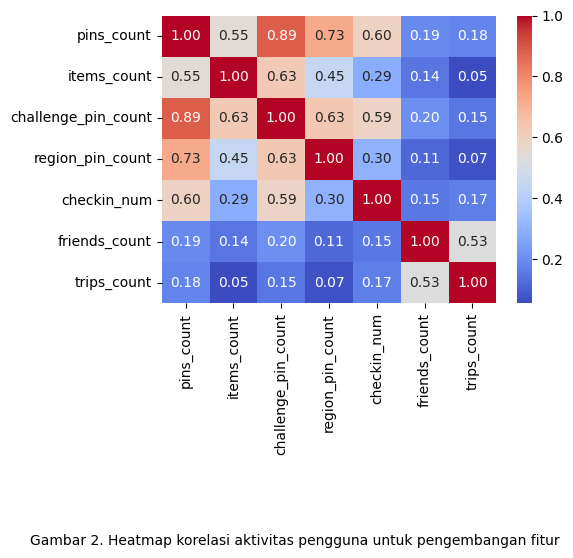

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pilih subset variabel yang relevan
selected_columns = ['pins_count', 'items_count', 'challenge_pin_count',
                    'region_pin_count', 'checkin_num', 'friends_count', 'trips_count']

# Matriks korelasi
correlation_matrix_subset = data_userinfo[selected_columns].corr()

# Visualisasi heatmap
plt.figure(figsize=(6, 5))  # Menyesuaikan ukuran gambar agar proporsional
sns.heatmap(correlation_matrix_subset, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)

# Menambahkan keterangan di bawah gambar
plt.figtext(0.5, -0.15, 'Gambar 2. Heatmap korelasi aktivitas pengguna untuk pengembangan fitur',
            horizontalalignment='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Mengatur layout agar tidak ada elemen yang terpotong
plt.show()

### 2.2.4. Pertanyaan 4: Apakah ada tren pertumbuhan jumlah check-in dari waktu ke waktu?

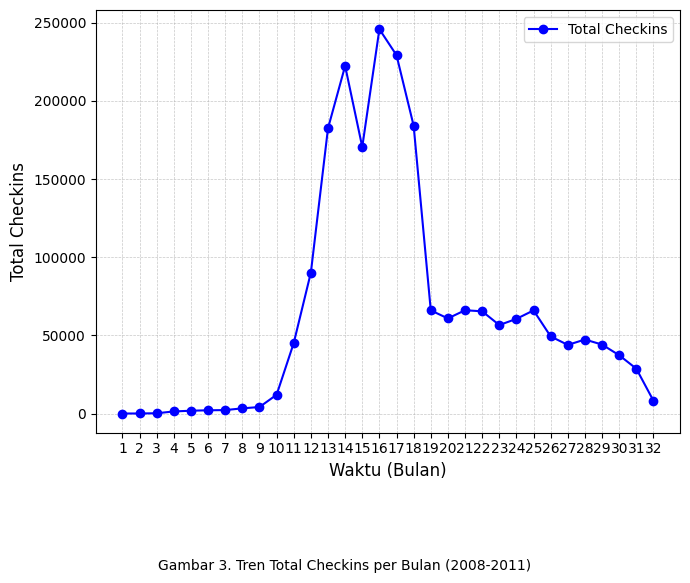

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Menggunakan angka 1 hingga 32 sebagai sumbu X
x = range(1, len(monthly_checkins) + 1)  # 1 hingga 32

# Plotting the data
plt.figure(figsize=(7, 5))
plt.plot(x, monthly_checkins['total_checkins'], marker='o', linestyle='-', color='b', label='Total Checkins')

# Adding labels and title
plt.xlabel("Waktu (Bulan)", fontsize=12)
plt.ylabel("Total Checkins", fontsize=12)
plt.figtext(0.5, -0.15, 'Gambar 3. Tren Total Checkins per Bulan (2008-2011)',
            horizontalalignment='center', fontsize=10)
plt.xticks(x)  # Menampilkan angka 1 hingga 32 di sumbu X
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend()

# Menampilkan plot
plt.tight_layout()
plt.show()

### 2.2.5. Pertanyaan 5: Apakah jumlah check-in dipengaruhi oleh musim atau waktu tertentu dalam setahun?

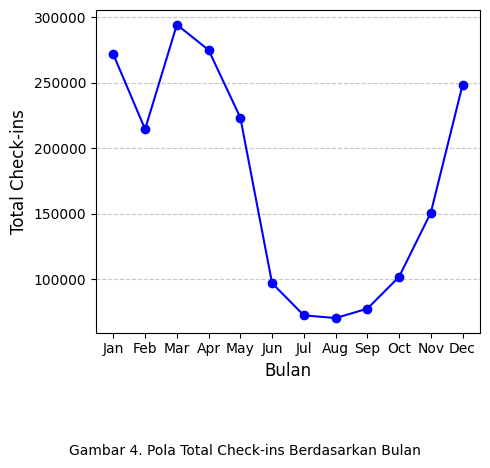

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Kelompokkan data berdasarkan bulan untuk menghitung total check-ins
checkins_by_month = monthly_checkins.groupby('bulan')['total_checkins'].sum()

# Kelompokkan data berdasarkan tahun untuk menghitung total check-ins
checkins_by_year = monthly_checkins.groupby('tahun')['total_checkins'].sum()

# Plot tren musiman berdasarkan bulan
plt.figure(figsize=(5, 4))
plt.plot(checkins_by_month.index, checkins_by_month.values, marker='o', linestyle='-', color='blue')
plt.figtext(0.5, -0.15, 'Gambar 4. Pola Total Check-ins Berdasarkan Bulan',
            horizontalalignment='center', fontsize=10)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Check-ins', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2.2.6. Pertanyaan 6: Negara mana yang paling sering dikunjungi oleh pengguna?

In [52]:
# Menampilkan semua negara yang unik dalam kolom 'country'
unique_countries = data_spots2_new['country'].unique()

# Menghitung jumlah kunjungan untuk setiap negara
country_counts = data_spots2_new['country'].value_counts()

# Menghapus 'Unknown' dari daftar negara
country_counts = country_counts[country_counts.index != 'Unknown']

# Mendapatkan 10 negara yang paling sering dikunjungi
top_10_countries = country_counts.head(10)

# Menampilkan hasil
print("\n10 negara yang paling sering dikunjungi (selain 'Unknown') beserta jumlah kunjungannya:")
print(top_10_countries)


10 negara yang paling sering dikunjungi (selain 'Unknown') beserta jumlah kunjungannya:
country
TX    4753
CA    4741
NY    2165
FL    1931
MI    1744
IL    1583
VA    1428
NC    1423
OH    1244
WA    1238
Name: count, dtype: int64


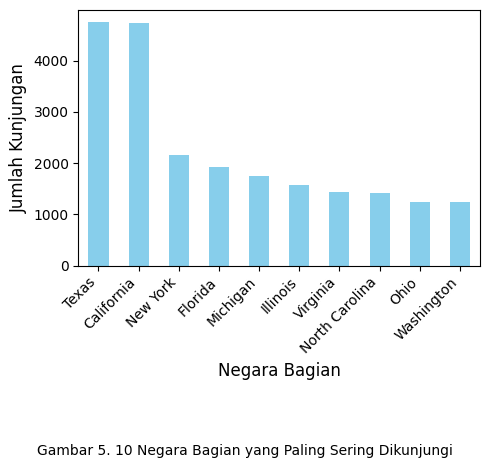

In [53]:
#Visualisasi 10 negara yang paling sering dikunjungi

import matplotlib.pyplot as plt

# Mapping kode negara bagian ke nama lengkap
state_mapping = {
    "TX": "Texas",
    "CA": "California",
    "NY": "New York",
    "FL": "Florida",
    "MI": "Michigan",
    "IL": "Illinois",
    "VA": "Virginia",
    "NC": "North Carolina",
    "OH": "Ohio",
    "WA": "Washington"
}

# Ganti kode dengan nama negara bagian
top_10_countries_named = top_10_countries.rename(index=state_mapping)

# Plot bar chart untuk 10 negara bagian yang paling sering dikunjungi
plt.figure(figsize=(5, 4))
top_10_countries_named.plot(kind='bar', color='skyblue')

# Menambahkan judul dan label sumbu
plt.figtext(0.5, -0.15, 'Gambar 5. 10 Negara Bagian yang Paling Sering Dikunjungi',
            horizontalalignment='center', fontsize=10)
plt.xlabel('Negara Bagian', fontsize=12)
plt.ylabel('Jumlah Kunjungan', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Memutar label negara bagian agar mudah dibaca
plt.tight_layout()
plt.show()

### 2.2.7. Pertanyaan 7: Negara apakah yang paling sering dikunjungi oleh pengguna dan lokasi apa saja yang paling sering dikunjungi pada negara tersebut?

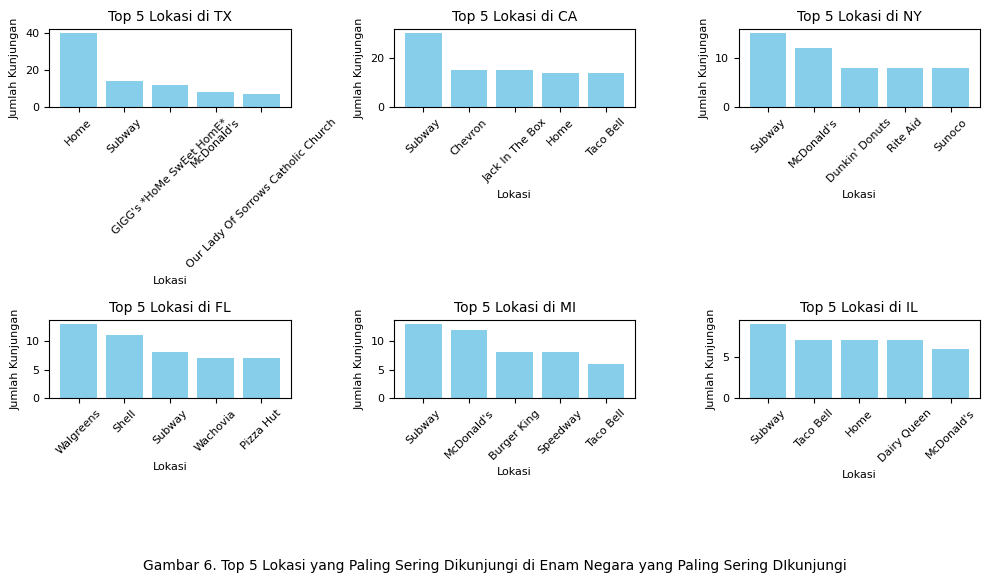

In [54]:
import matplotlib.pyplot as plt

# Daftar negara yang ingin ditampilkan
selected_countries = ['TX', 'CA', 'NY', 'FL', 'MI', 'IL']

# Filter data berdasarkan negara yang dipilih dan hilangkan 'Unknown'
filtered_data = data_spots2_new[
    (data_spots2_new['country'].isin(selected_countries)) &
    (data_spots2_new['name'] != 'Unknown')
]

# Dictionary untuk menyimpan top 5 lokasi per negara
top_locations_dict = {}

# Ambil 5 lokasi teratas per negara
for country in selected_countries:
    top_locations = (
        filtered_data[filtered_data['country'] == country]['name']
        .value_counts()
        .head(5)  # Ambil 5 lokasi teratas
    )
    top_locations_dict[country] = top_locations

# Visualisasi: Subplots dalam layout berbentuk matrix
rows = 2
cols = 3  # Menyesuaikan jumlah negara
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 5))

# Flatten axes untuk iterasi lebih mudah
axes = axes.flatten()

for i, (country, locations) in enumerate(top_locations_dict.items()):
    ax = axes[i]
    ax.bar(locations.index, locations.values, color='skyblue')
    ax.set_title(f"Top 5 Lokasi di {country}", fontsize=10)
    ax.set_xlabel('Lokasi', fontsize=8)
    ax.set_ylabel('Jumlah Kunjungan', fontsize=8)
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)  # Rotasi label untuk menghemat ruang
    ax.tick_params(axis='y', labelsize=8)

# Hapus subplot kosong jika jumlah negara kurang dari rows * cols
for j in range(len(top_locations_dict), rows * cols):
    fig.delaxes(axes[j])

plt.figtext(0.5, -0.15, 'Gambar 6. Top 5 Lokasi yang Paling Sering Dikunjungi di Enam Negara yang Paling Sering DIkunjungi',
            horizontalalignment='center', fontsize=10)
plt.tight_layout()
plt.show()

### 2.2.8. Pertanyaan 8: Kategori lokasi apakah yang paling sering dikunjungi oleh pengguna?

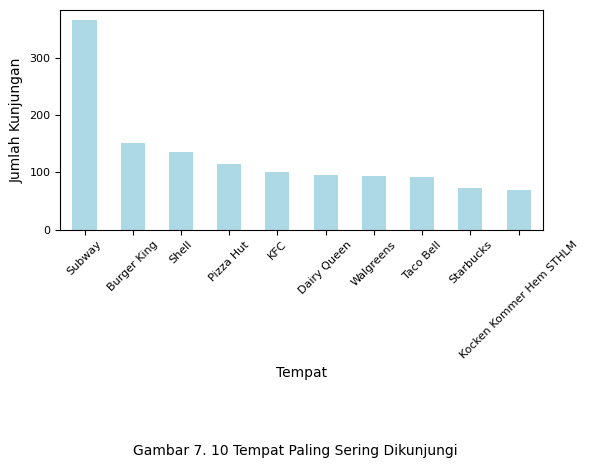

In [55]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# Misalkan data_spots2 sudah ada dan berisi kolom 'name'
# Filter data untuk hanya menyertakan nama dengan huruf biasa dan spasi, tanpa 'Unknown' dan 'Home'
data_spots2['filtered_name'] = data_spots2['name'].apply(
    lambda x: x if isinstance(x, str) and re.fullmatch(r'[a-zA-Z\s]+', x) and x not in ['Unknown', 'Home', 'Home Sweet Home'] else None
)

# Menghitung jumlah kunjungan untuk setiap tempat di kolom 'filtered_name'
top_places = data_spots2['filtered_name'].value_counts().head(10)

# Visualisasi data
plt.figure(figsize=(6, 4))
top_places.plot(kind='bar', color='lightblue')
plt.figtext(0.5, -0.15, 'Gambar 7. 10 Tempat Paling Sering Dikunjungi',
            horizontalalignment='center', fontsize=10)
plt.xlabel("Tempat", fontsize=10)
plt.ylabel("Jumlah Kunjungan", fontsize=10)
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

# Menyimpan plot sebagai PDF dengan margin dan center
plt.tight_layout()
plt.savefig("visualisasi_centered.pdf", bbox_inches='tight', pad_inches=0.5, dpi=100)  # Tambahkan padding di sini
plt.show()


### 2.2.9. Pertanyaan 9: Dari banyaknya pengguna yang melakukan checkin, lokasi mana yang sering dijadikan untuk melakukan checkin?

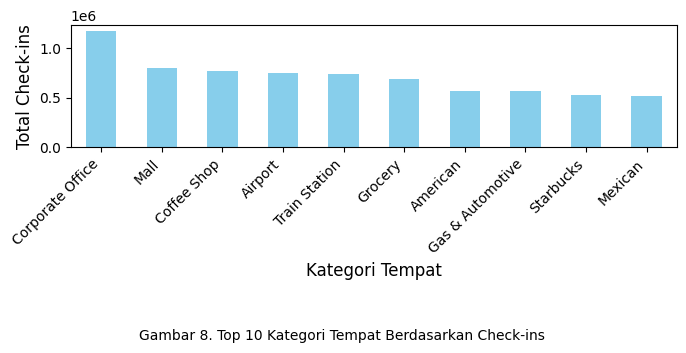

In [69]:
#Jumlah Check-ins Berdasarkan Kategori Tempat (spot_categories):

# Ekstrak nama kategori dari kolom spot_categories
data_spots1['category_name'] = data_spots1['spot_categories'].apply(lambda x: eval(x)[0]['name'])
category_checkins = data_spots1.groupby('category_name')['checkins_count'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(7, 3))
category_checkins.plot(kind='bar', color='skyblue')
plt.figtext(0.5, -0.15, 'Gambar 8. Top 10 Kategori Tempat Berdasarkan Check-ins',
            horizontalalignment='center', fontsize=10)
plt.xlabel('Kategori Tempat', fontsize=12)
plt.ylabel('Total Check-ins', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.2.10. Pertanyaan 10: Pada bulan apakah banyak pengguna melakukan checkins?

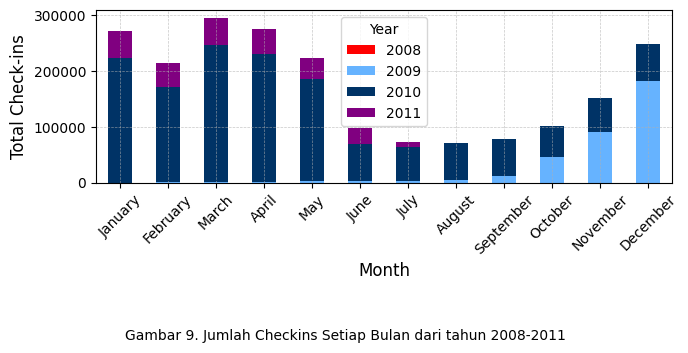

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# Menggabungkan tahun dan bulan untuk sumbu X
monthly_checkins['month_year'] = pd.to_datetime(monthly_checkins['tahun'].astype(str) + '-' + monthly_checkins['bulan'].astype(str) + '-01')

# Menambahkan kolom bulan untuk digunakan di sumbu X
monthly_checkins['bulan'] = monthly_checkins['month_year'].dt.month_name()

# Pivoting the data to get the total check-ins for each month and year
pivot_table = monthly_checkins.pivot_table(index='bulan', columns='tahun', values='total_checkins', aggfunc='sum', fill_value=0)

# Mengurutkan bulan
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
pivot_table = pivot_table.reindex(months_order)

# Plotting the stacked bar chart
plt.figure(figsize=(7, 3))
# Mengubah urutan warna: 2008 (merah), 2009 (biru muda), 2010 (biru tua), 2011 (ungu)
pivot_table.plot(kind='bar', stacked=True, color=['#FF0000', '#66B3FF', '#003366', '#800080'], ax=plt.gca())

# Adding labels and title
plt.figtext(0.5, -0.15, 'Gambar 9. Jumlah Checkins Setiap Bulan dari tahun 2008-2011',
            horizontalalignment='center', fontsize=10)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Check-ins", fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='Year')
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Displaying the plot
plt.tight_layout()
plt.show()

### 2.2.11. Pertanyaan 11: Pada jam berapa pengguna paling aktif melakukan check-in?

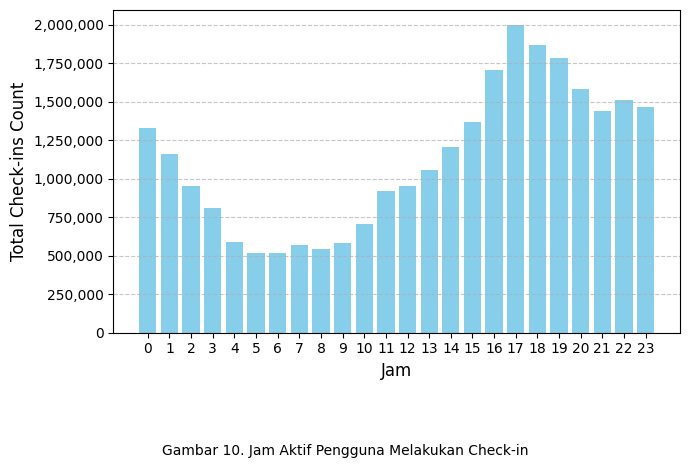

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# Kelompokkan data berdasarkan jam (kolom 'waktu') dan jumlahkan check-ins
jam_aktif = data_spots1.groupby('waktu')['checkins_count'].sum()

# Plot bar chart
plt.figure(figsize=(7, 4))
plt.bar(jam_aktif.index, jam_aktif.values, color='skyblue')

# Format sumbu Y agar menampilkan angka sebagai bilangan bulat
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Tambahkan label dan judul
plt.figtext(0.5, -0.15, 'Gambar 10. Jam Aktif Pengguna Melakukan Check-in',
            horizontalalignment='center', fontsize=10)
plt.xlabel('Jam', fontsize=12)
plt.ylabel('Total Check-ins Count', fontsize=12)
plt.xticks(range(0, 24))  # Menampilkan seluruh jam (0-23)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tampilkan plot
plt.tight_layout()
plt.show()

### 2.2.12. Pertanyaan 12: Apakah jumlah lokasi yang dikunjungi oleh pengguna memengaruhi jumlah check-in yang dilakukan?

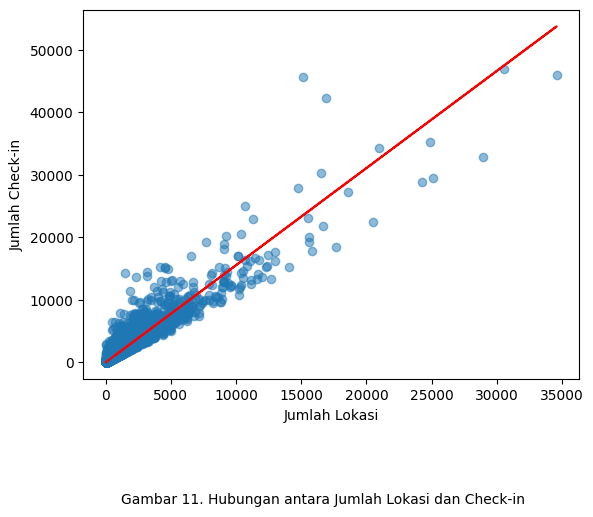

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# Scatter plot antara places_num (jumlah lokasi) dan checkin_num (jumlah check-in)
plt.scatter(data_userinfo['places_num'], data_userinfo['checkin_num'], alpha=0.5)

# Menambahkan garis regresi berwarna merah
slope, intercept = np.polyfit(data_userinfo['places_num'], data_userinfo['checkin_num'], 1)
plt.plot(data_userinfo['places_num'], slope * data_userinfo['places_num'] + intercept, color='red')

# Menambahkan judul dan label
plt.figtext(0.5, -0.15, 'Gambar 11. Hubungan antara Jumlah Lokasi dan Check-in',
            horizontalalignment='center', fontsize=10)
plt.xlabel('Jumlah Lokasi')
plt.ylabel('Jumlah Check-in')

# Menampilkan plot
plt.show()